# Non-targeting and safe-targeting controls.

This notebook analyses control guides in the validation screens.

Kexin Dong

Dec 12, 2025

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

## 1. normalize thre read counts of each sample to RPM (reads per million).

In [2]:
#loading in barcode counts
ABE_BC_COUNTS = pd.read_csv('ABE_BC_COUNTS.txt', sep='\t')
CBE_BC_COUNTS = pd.read_csv('CBE_BC_COUNTS.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv('ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv('CBE_EPO_COUNTS.txt', sep='\t')

In [ ]:
#visualizing the null distributions

fig, ax = plt.subplots(2,5, figsize=(15,6), sharex=True, sharey=False)

conditions = ['d5', 'd15', 'spleen', 'bm', 'men']
name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))

for idx, condition in enumerate(conditions):
    bins = np.linspace(-11,8,80)

    ax[0][idx].hist(ABE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:purple', label='Bootstrapped\nNull (ABE)')
    ax[1][idx].hist(CBE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:blue', label='Bootstrapped\nNull (CBE)')

    ax[0][idx].set_title(name_dict[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);
    
    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])

    #also plot the replicates
    samp_of_interest_CBE = CBE_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_SAMP_DICT[condition]

    for idx2, k in enumerate(samp_of_interest_ABE):
        if idx2==0:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    for idx2, k in enumerate(samp_of_interest_CBE):
        if idx2==0:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()
plt.savefig('figures/null_versus_bc.pdf')

In [3]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_BC_COUNTS.columns[2:])
ABE_BC_RPM = ABE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_BC_RPM[k] = rpm

In [4]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_EPO_COUNTS.columns[2:])
ABE_EPO_RPM = ABE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_EPO_RPM[k] = rpm

In [5]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_BC_COUNTS.columns[2:])
CBE_BC_RPM = CBE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_BC_RPM[k] = rpm

In [6]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_EPO_COUNTS.columns[2:])
CBE_EPO_RPM = CBE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_EPO_RPM[k] = rpm

## 2. Generate LFC tables

In [7]:
#start with ABE

def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3']):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation
    """

    dmso_median = np.median(RPM_df[t0_comparison], axis=1)

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/dmso_median)
            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [8]:
ABE_EPO_samps_to_merge = ABE_BC_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
ABE_EPO_new_name = ABE_BC_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

CBE_BC_samps_to_merge = [['bm1', 'bm2', 'bm4'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5-rep1', 'd5-rep2', 'd5-rep3','d5-rep4', 'd5-rep5'],
['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'],
['lib'],
['men1', 'men2', 'men4'], 
['spleen1', 'spleen2', 'spleen4']]
CBE_BC_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

CBE_EPO_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5-rep1', 'd5-rep2', 'd5-rep3','d5-rep4', 'd5-rep5'],
['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'],
['lib'],
['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
CBE_EPO_new_name = ['bm', 'd15', 'd5','input','lib','men', 'spleen']

In [9]:
ABE_EPO_SAMP_DICT = ABE_BC_SAMP_DICT = dict(zip(ABE_EPO_new_name, ABE_EPO_samps_to_merge))
CBE_BC_SAMP_DICT = dict(zip(CBE_BC_new_name, CBE_BC_samps_to_merge))
CBE_EPO_SAMP_DICT = dict(zip(CBE_EPO_new_name, CBE_EPO_samps_to_merge))

In [10]:
#generate LFC tables
ABE_EPO_LFC = LFC_table_generator(ABE_EPO_RPM, ABE_EPO_SAMP_DICT, t0_comparison=['input'])
CBE_EPO_LFC = LFC_table_generator(CBE_EPO_RPM, CBE_EPO_SAMP_DICT, t0_comparison=['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'])
ABE_BC_LFC = LFC_table_generator(ABE_BC_RPM, ABE_BC_SAMP_DICT, t0_comparison=['input'])
CBE_BC_LFC = LFC_table_generator(CBE_BC_RPM, CBE_BC_SAMP_DICT, t0_comparison=['input-rep1','input-rep2','input-rep3','input-rep4','input-rep5'])


In [11]:
fp = '/Users/kexindong/Documents/GitHub/PhD-FSR-MH-Lab/07_B-ALL_resubmission_20250819/validation_screen_analysis/MLE'
D5_ABE_BC = pd.read_csv(os.path.join(fp,'ABE_BC','d5.csv'))
D5_ABE_EPO = pd.read_csv(os.path.join(fp,'ABE_EPO','d5.csv'))
D5_CBE_BC = pd.read_csv(os.path.join(fp,'CBE_BC','d5.csv'))
D5_CBE_EPO = pd.read_csv(os.path.join(fp,'CBE_EPO','d5.csv'))

In [12]:
#and then adding in editing information to the dataframe
ABE_EPO_EDITING = D5_ABE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_EPO_EDITING = ABE_EPO_EDITING[ABE_EPO_EDITING['gRNA_id'].isin(ABE_EPO_COUNTS['sgRNA'])]

CBE_EPO_EDITING = D5_CBE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_EPO_EDITING = CBE_EPO_EDITING[CBE_EPO_EDITING['gRNA_id'].isin(CBE_EPO_COUNTS['sgRNA'])]

ABE_BC_EDITING = D5_ABE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_BC_EDITING = ABE_BC_EDITING[ABE_BC_EDITING['gRNA_id'].isin(ABE_BC_COUNTS['sgRNA'])]

CBE_BC_EDITING = D5_CBE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_BC_EDITING = CBE_BC_EDITING[CBE_BC_EDITING['gRNA_id'].isin(CBE_BC_COUNTS['sgRNA'])]

In [13]:
#also add in information about the edits of interest
library = pd.read_csv('FINAL_focused_library.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
library

,gRNA_id,gene_name_m_corrected,gene_name_h,HGVSp_m,HGVSp_h,classification,classification_m
0,gRNA_2,Abl1,ABL1,Non-coding,NaN,targeting guide,Intron
1,gRNA_4,Abl1,ABL1,E1060K,E1048K,targeting guide,Missense
2,gRNA_19,Abl1,ABL1,P592L,P573L,targeting guide,Missense
3,gRNA_21,Abl1,ABL1,A737T,A719T,targeting guide,Missense
4,gRNA_85,Akt1,AKT1,D323G,D323G,targeting guide,Missense
...,...,...,...,...,...,...,...
1628,gRNA_15007,NaN,NaN,NaN,NaN,non-targeting control,NaN
1629,gRNA_15008,NaN,NaN,NaN,NaN,non-targeting control,NaN
1630,gRNA_15009,NaN,NaN,NaN,NaN,non-targeting control,NaN
1631,gRNA_15010,NaN,NaN,NaN,NaN,non-targeting control,NaN


In [14]:
library['classification'].unique()

array(['targeting guide', 'non-targeting control',
       'essential truncation guide', 'safe-targeting control'],
      dtype=object)

In [15]:
ABE_EPO_EDITING = pd.merge(ABE_EPO_EDITING, library, on='gRNA_id')
ABE_BC_EDITING = pd.merge(ABE_BC_EDITING, library, on='gRNA_id')
CBE_EPO_EDITING = pd.merge(CBE_EPO_EDITING, library, on='gRNA_id')
CBE_BC_EDITING = pd.merge(CBE_BC_EDITING, library, on='gRNA_id')

In [16]:
ABE_BC_LFC_table_w_editing = pd.merge(ABE_BC_LFC, ABE_BC_EDITING, on='gRNA_id')
ABE_EPO_LFC_table_w_editing = pd.merge(ABE_EPO_LFC, ABE_EPO_EDITING, on='gRNA_id')
CBE_BC_LFC_table_w_editing = pd.merge(CBE_BC_LFC, CBE_BC_EDITING, on='gRNA_id')
CBE_EPO_LFC_table_w_editing = pd.merge(CBE_EPO_LFC, CBE_EPO_EDITING, on='gRNA_id')

In [17]:
#calculating z-scores for standardization of comparison
samples = ['bm', 'd15', 'd5', 'men', 'spleen']
def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

ABE_BC_LFC_table_w_editing_z_score = ABE_BC_LFC_table_w_editing.copy()
ABE_EPO_LFC_table_w_editing_z_score = ABE_EPO_LFC_table_w_editing.copy()
CBE_BC_LFC_table_w_editing_z_score = CBE_BC_LFC_table_w_editing.copy()
CBE_EPO_LFC_table_w_editing_z_score = CBE_EPO_LFC_table_w_editing.copy()

ABE_BC_LFC_table_w_editing_z_score = z_score(ABE_BC_LFC_table_w_editing_z_score, samples)
ABE_EPO_LFC_table_w_editing_z_score = z_score(ABE_EPO_LFC_table_w_editing_z_score, samples)
CBE_BC_LFC_table_w_editing_z_score = z_score(CBE_BC_LFC_table_w_editing_z_score, samples)
CBE_EPO_LFC_table_w_editing_z_score = z_score(CBE_EPO_LFC_table_w_editing_z_score, samples)

# Evaluating LFCs of control guides

## Correlation of LFC of NT/ ST guides, validation EPO, validation BC, original

In [18]:
# read in the og files
ABE_OG_LFC = pd.read_csv('ABE_LFC_FDR_df_og.csv')
CBE_OG_LFC = pd.read_csv('CBE_LFC_FDR_df_og.csv')
null=['non-targeting control', 'safe-targeting control']

In [19]:
#calculating z-scores for OG
samples = ['bonemarrow', 'd15', 'd5', 'meninges', 'spleen']
def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

ABE_OG_LFC_z = ABE_OG_LFC.copy()
CBE_OG_LFC_z = CBE_OG_LFC.copy()

ABE_OG_LFC_z = z_score(ABE_OG_LFC_z, samples)
CBE_OG_LFC_z = z_score(CBE_OG_LFC_z, samples)

In [20]:
ABE_BC_controls = ABE_BC_LFC_table_w_editing_z_score[ABE_BC_LFC_table_w_editing_z_score['classification'].isin(null)].reset_index(drop=True)
ABE_EPO_controls = ABE_EPO_LFC_table_w_editing_z_score[ABE_EPO_LFC_table_w_editing_z_score['classification'].isin(null)].reset_index(drop=True)
ABE_OG_controls = ABE_OG_LFC_z[ABE_OG_LFC_z['classification'].isin(null)].reset_index(drop=True)

CBE_BC_controls = CBE_BC_LFC_table_w_editing_z_score[CBE_BC_LFC_table_w_editing_z_score['classification'].isin(null)].reset_index(drop=True)
CBE_EPO_controls = CBE_EPO_LFC_table_w_editing_z_score[CBE_EPO_LFC_table_w_editing_z_score['classification'].isin(null)].reset_index(drop=True)
CBE_OG_controls = CBE_OG_LFC_z[CBE_OG_LFC_z['classification'].isin(null)].reset_index(drop=True)

### Venn plot for controls

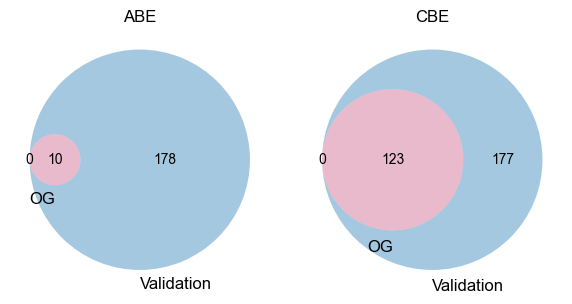

In [21]:
fig, ax = plt.subplots(1,2,figsize = (6,3))
list1 = ABE_OG_controls[ABE_OG_controls['classification']=='non-targeting control']['gRNA_id']
list2 = ABE_BC_controls[ABE_BC_controls['classification']=='non-targeting control']['gRNA_id']
venn2([set(list1), set(list2)], set_labels=('OG', 'Validation'), set_colors=("red", "tab:blue"), ax=ax[0])
ax[0].set_title('ABE')
list1 = CBE_OG_controls[CBE_OG_controls['classification']=='non-targeting control']['gRNA_id']
list2 = CBE_BC_controls[CBE_BC_controls['classification']=='non-targeting control']['gRNA_id']
venn2([set(list1), set(list2)], set_labels=('OG', 'Validation'), set_colors=("red", "tab:blue"), ax=ax[1])
ax[1].set_title('CBE')
plt.savefig('figures/venn_validation_og_guides_NTs.pdf')
fig.tight_layout()

### Correlation plot for median LFC for NTs only, OG vs validation, stratified by tissues

In [22]:
ABE_OG_controls

,gRNA_id,Gene,spleen1,spleen2,spleen3,spleen4,LFC_avg_spleen,LFC_median_spleen,Input_median,bonemarrow1,...,p_low_unadjusted_meninges_stouffers,FDR_high_meninges_stouffers,FDR_low_meninges_stouffers,FDR_meninges_fishers,FDR_meninges_stouffers,z_score_bonemarrow,z_score_d15,z_score_d5,z_score_meninges,z_score_spleen
0,gRNA_13260,safe_target,-0.926702,-0.844685,-1.228059,-0.461746,-0.865298,-0.885693,953.164324,0.319052,...,0.750702,0.887909,1.000000,0.999392,0.887909,-0.474320,-0.196631,-0.144131,0.817514,-0.848315
1,gRNA_13261,safe_target,-1.548780,-0.253415,-0.654316,1.029199,-0.356828,-0.453866,598.777837,0.972126,...,0.683592,0.973905,1.000000,0.999974,0.973905,0.847836,-1.178728,-0.047903,-0.297966,-0.398530
2,gRNA_13262,safe_target,0.313814,0.413562,0.951947,0.730690,0.602503,0.572126,382.817693,-0.523171,...,0.437428,1.000000,0.917741,0.999974,0.917741,-0.303682,-0.332163,-0.888947,0.216568,0.670127
3,gRNA_13263,safe_target,0.604393,-0.295642,-0.021201,-0.083533,0.051004,-0.052367,1209.859328,-0.542905,...,0.903729,0.643161,1.000000,0.765697,0.643161,0.058013,0.159246,0.060826,1.037150,0.019665
4,gRNA_13264,safe_target,1.080976,0.414635,0.358798,1.177934,0.758085,0.747805,1358.063907,0.567289,...,0.846914,0.721729,1.000000,0.933796,0.721729,-0.039397,-0.203852,-0.246746,0.920838,0.853112
5,gRNA_13265,safe_target,-0.573887,-1.203134,-1.386990,-0.487993,-0.913001,-0.888510,1165.266019,-1.600258,...,0.907641,0.632145,1.000000,0.824051,0.632145,-0.832637,-0.558207,-0.325809,1.230026,-0.851249
6,gRNA_13266,safe_target,0.634431,-0.197680,-0.148455,0.574938,0.215809,0.213241,967.390658,-0.380783,...,0.889348,0.655152,1.000000,0.866704,0.655152,-0.124723,-0.329305,-0.056471,0.754986,0.296319
7,gRNA_13267,safe_target,1.144393,0.421058,1.340878,0.030826,0.734289,0.782726,656.194890,-0.218296,...,0.383376,1.000000,0.899682,0.774293,0.899682,-0.189231,-0.096477,-0.372431,-1.134702,0.889485
8,gRNA_13268,safe_target,0.913719,-1.100524,0.536566,0.049921,0.099921,0.293243,298.752997,0.044457,...,0.184169,1.000000,0.711411,0.693725,0.711411,0.324436,-0.329305,0.292348,0.013292,0.379648
9,gRNA_13269,safe_target,1.360829,0.151946,0.944962,1.047269,0.876252,0.996116,641.478297,0.799990,...,0.982917,0.342212,1.000000,0.503844,0.342212,0.095950,-0.429792,-0.190374,1.277735,1.111748


In [23]:
yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

10
10
10
10
5
123
5
123
5
123
5
123


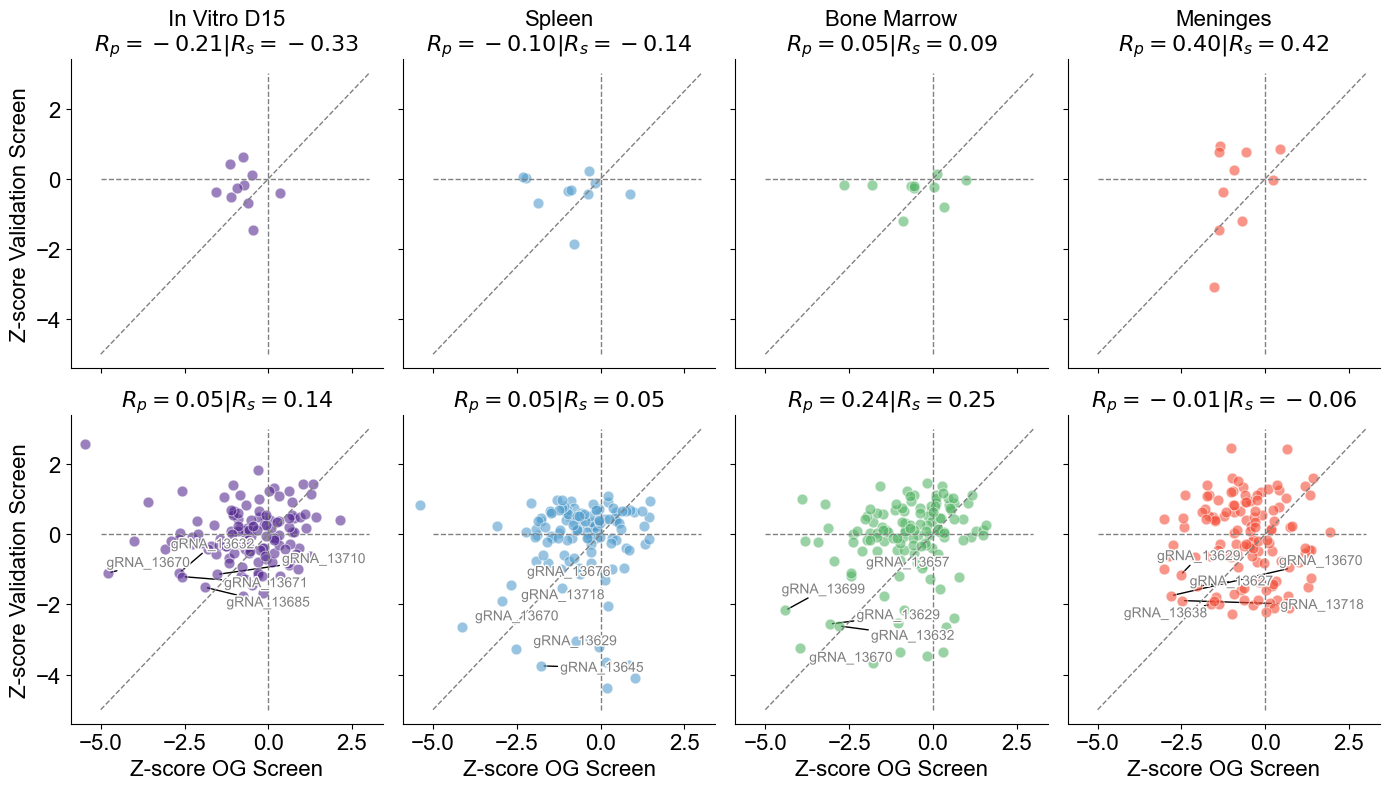

In [24]:
fig, ax = plt.subplots(2, 4, figsize = (14, 8), sharex=True, sharey = True)

name_dict = dict(zip(
    ['bm', 'd15', 'd5', 'men', 'spleen'],
    ['Bone Marrow','In Vitro D15','D5','Meninges','Spleen']
))
color_dict =  dict(zip(
    ['bm', 'd15', 'd5', 'men', 'spleen'],
    [greens[3],purples[5],purples[2],reds[3],blues[3]]
))

# ABE first
for i, (samp1, samp2) in enumerate(zip(['d15', 'spleen','bm', 'men'],['d15',  'spleen', 'bonemarrow', 'meninges',])):
    val = ABE_EPO_controls[['gRNA_id',f'z_score_{samp1}']]
    val.columns = ['gRNA_id','validation_z_score']
    og = ABE_OG_controls[['gRNA_id',f'z_score_{samp2}']]
    og.columns = ['gRNA_id','og_z_score']
    df = pd.merge(val, og)

    # correlation calculation 
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['og_z_score'], df['validation_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['og_z_score'], df['validation_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    print(len(df))
    sns.scatterplot(data=df, x='og_z_score', y='validation_z_score',ax=ax[0][i], color = color_dict[samp1],s=60, alpha=.6)
    ax[0][i].spines[['top', 'right']].set_visible(False)
    ax[0][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[0][i].plot([-5,3],[-5,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([0,0],[-5,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([-5,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].set_title(f'{name_dict[samp1]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[0][i].set_ylabel(f'Z-score Validation Screen', fontsize=16)
    
# then CBE
for i, (samp1, samp2) in enumerate(zip(['d15', 'spleen','bm', 'men'],['d15',  'spleen', 'bonemarrow', 'meninges',])):
    val = CBE_EPO_controls[['gRNA_id',f'z_score_{samp1}']]
    val.columns = ['gRNA_id','validation_z_score']
    og = CBE_OG_controls[['gRNA_id',f'z_score_{samp2}']]
    og.columns = ['gRNA_id','og_z_score']
    df = pd.merge(val, og)

    tb = df[(df['og_z_score']<-1) & (df['validation_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='og_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'validation_z_score'])
            x.append(val2['og_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[1][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        adjust_text(texts,only_move={'texts':'xy'}, ax=ax[1][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))

    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['og_z_score'], df['validation_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['og_z_score'], df['validation_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    print(len(df))
    sns.scatterplot(data=df, x='og_z_score', y='validation_z_score',ax=ax[1][i], color = color_dict[samp1],s=60, alpha=.6)
    ax[1][i].spines[['top', 'right']].set_visible(False)
    ax[1][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[1][i].plot([-5,3],[-5,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([0,0],[-5,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([-5,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].set_title(f'$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[1][i].set_xlabel('Z-score OG Screen', fontsize=16)
    ax[1][i].set_ylabel('Z-score Validation Screen', fontsize=16)

fig.tight_layout()
plt.savefig('figures/NT_correlation.pdf')

### Correlation plot for median LFC for all control guides, ST + NT, EPO vs BC, stratified by tissues

5
206
5
206
5
206
5
206
360
5
360
5
360
5
360
5


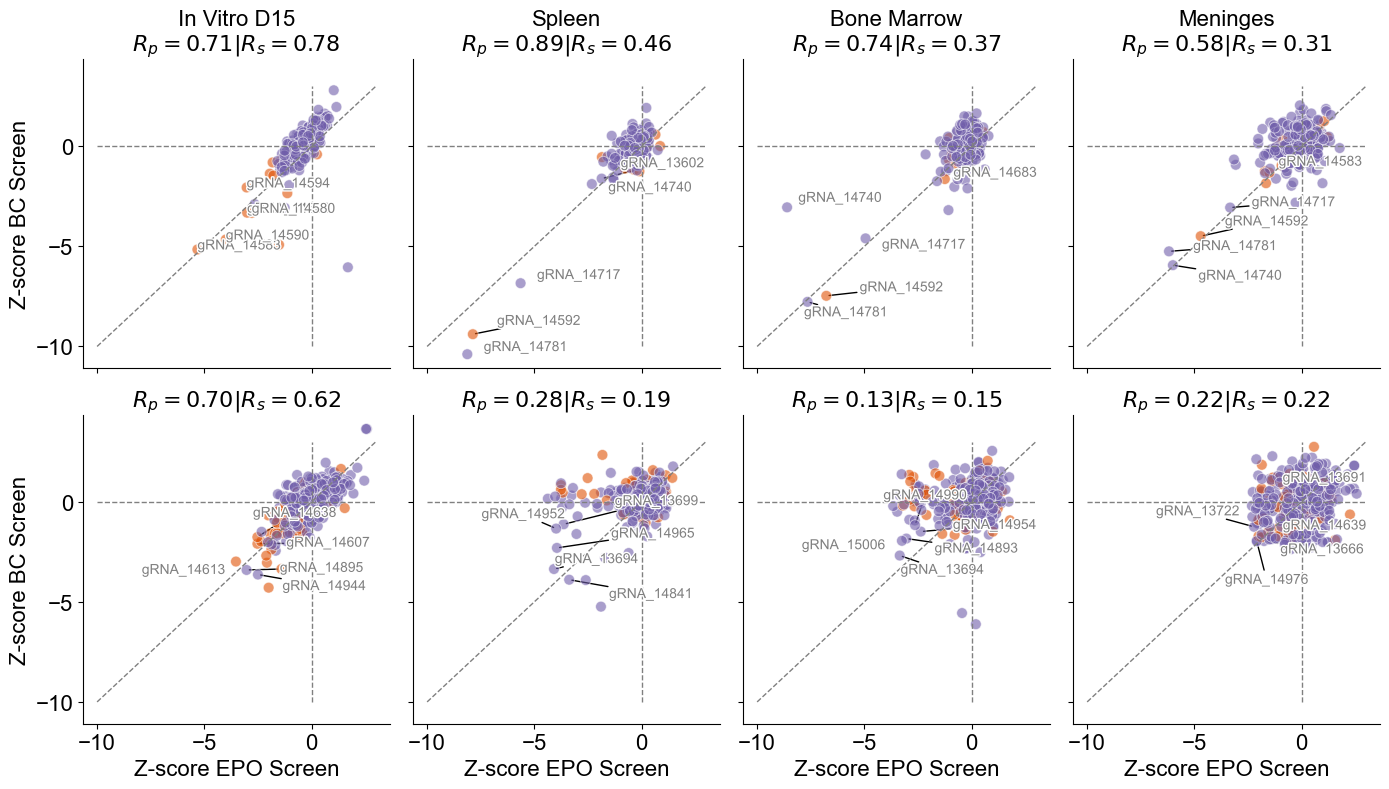

In [ ]:
fig, ax = plt.subplots(2, 4, figsize = (14, 8), sharex=True, sharey = True)

name_dict = dict(zip(
    ['bm', 'd15', 'd5', 'men', 'spleen'],
    ['Bone Marrow','In Vitro D15','D5','Meninges','Spleen']
))
color_dict =  dict(zip(
    ['bm', 'd15', 'd5', 'men', 'spleen'],
    [greens[3],purples[5],purples[2],reds[3],blues[3]]
))

# ABE first
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = ABE_EPO_controls[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = ABE_BC_controls[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc)

    # correlation calculation 
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)


    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        if i >0:
            adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    print(len(df))
    color_dict_classification = {'non-targeting control':purples[4], 'safe-targeting control':yellows[4]}
    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[0][i], hue='classification', palette=color_dict_classification, s=60, alpha=.6, legend=False)
    ax[0][i].spines[['top', 'right']].set_visible(False)
    ax[0][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[0][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[0][i].set_title(f'{name_dict[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[0][i].set_ylabel(f'Z-score BC Screen', fontsize=16)
    
# then CBE
for i, samp in enumerate(['d15', 'spleen','bm', 'men']):
    epo = CBE_EPO_controls[['gRNA_id',f'z_score_{samp}','classification']]
    epo.columns = ['gRNA_id','epo_z_score','classification']
    bc = CBE_BC_controls[['gRNA_id',f'z_score_{samp}']]
    bc.columns = ['gRNA_id','bc_z_score']
    df = pd.merge(epo, bc)
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
    spearman = "{:.2f}".format(corr_spearman)
    pearson = "{:.2f}".format(corr_pearson)

    print(len(df))


    tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

    if len(tb)>0:
        tb = tb.reset_index(drop=True)
        tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
        t = []
        x = []
        y = []
        c = []
        # print(val)
        for _, val2 in tb.iterrows():
            y.append(val2[f'bc_z_score'])
            x.append(val2['epo_z_score'])
            c.append('gray')
            t.append(val2['gRNA_id'])

        print(len(x))
        texts = [ax[1][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
        adjust_text(texts,only_move={'texts':'xy'}, ax=ax[1][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))

    sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[1][i], hue='classification', palette=color_dict_classification, s=60, alpha=.6, legend=False)
    ax[1][i].spines[['top', 'right']].set_visible(False)
    ax[1][i].tick_params(axis='both', which='major', labelsize=16,)
    ax[1][i].plot([-10,3],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([0,0],[-10,3], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].plot([-10,3],[0,0], linestyle='dashed', color='gray', linewidth=1)
    ax[1][i].set_title(f'$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 16)
    ax[1][i].set_xlabel('Z-score EPO Screen', fontsize=16)
    ax[1][i].set_ylabel('Z-score BC Screen', fontsize=16)

fig.tight_layout()
plt.savefig('figures/NT_correlation_epo_bc.pdf')

In [ ]:
fig, ax = plt.subplots(3,10,figsize=(20,6), sharey=True, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(CBE_BC_COUNTS.columns):
            samp = list(CBE_BC_COUNTS.columns)[num_samp]
            bins=np.linspace(0,50000, 81)
            ax[i][k].hist(np.clip(CBE_BC_COUNTS[samp], bins[0], bins[-1]), bins=bins,color=blues[2], edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(DICT_CBE_BC[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([10000*x for x in [0,1,2,3,4,5]])
            ax[i][k].set_xticklabels([
                '0',
                '10',
                '20',
                '30',
                '40',
                '50K+'
            ])
            #ax.hist[]

for i in range(5,10):
    fig.delaxes(ax[2][i])
    ax[1][i].tick_params(labelbottom=True)

fig.suptitle('CBE Barcoding', fontsize=16)
fig.tight_layout()
fig.savefig('figures/hist_cbe_bc.pdf')

### Do it for ABE per replicate

In [ ]:
NAMES_ABE_BC = NAMES_ABE_EPO = [
    'Plasmid','Input (D0)',
    'D5',
    'D15 REP1','D15 REP2','D15 REP3','D15 REP4','D15 REP5',
    'S1','S2','S3','S4','S5',
    'BM1','BM2','BM3','BM4','BM5',
    'M1','M2','M3','M4','M5'
]
DICT_ABE_BC = DICT_ABE_EPO = dict(zip(list(ABE_BC_COUNTS.columns[2:]), NAMES_ABE_BC))
DICT_ABE_BC

{'lib': 'Plasmid',
 'input': 'Input (D0)',
 'd5': 'D5',
 'd15-rep1': 'D15 REP1',
 'd15-rep2': 'D15 REP2',
 'd15-rep3': 'D15 REP3',
 'd15-rep4': 'D15 REP4',
 'd15-rep5': 'D15 REP5',
 'spleen1': 'S1',
 'spleen2': 'S2',
 'spleen3': 'S3',
 'spleen4': 'S4',
 'spleen5': 'S5',
 'bm1': 'BM1',
 'bm2': 'BM2',
 'bm3': 'BM3',
 'bm4': 'BM4',
 'bm5': 'BM5',
 'men1': 'M1',
 'men2': 'M2',
 'men3': 'M3',
 'men4': 'M4',
 'men5': 'M5'}

206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206


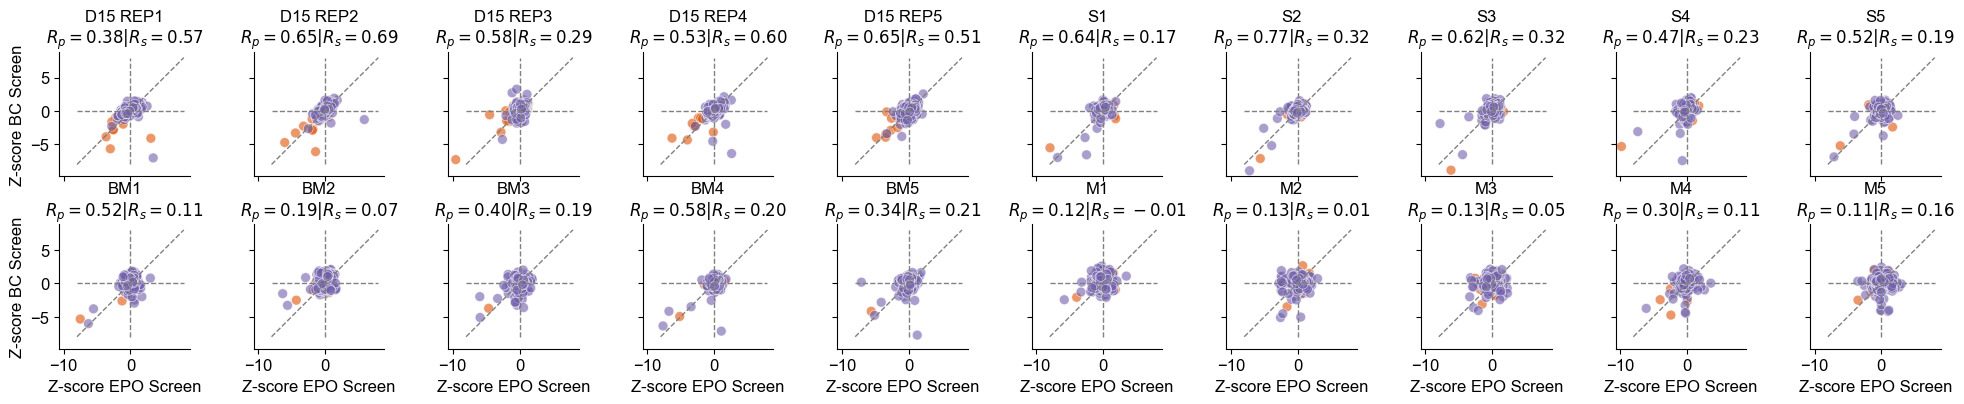

In [ ]:
fig, ax = plt.subplots(2,10,figsize=(20,4), sharey=True, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(ABE_BC_COUNTS.columns[5:]):
            samp = list(ABE_BC_COUNTS.columns)[5:][num_samp]
            
            epo = ABE_EPO_controls[['gRNA_id',samp,'classification']]
            avg = np.average(epo[samp])
            std = np.std(epo[samp])
            epo[f'epo_z_score'] = (epo[samp]-avg)/std
            epo = epo[['gRNA_id','epo_z_score','classification']]

            bc = ABE_BC_controls[['gRNA_id',samp, 'classification']]
            avg = np.average(bc[samp])
            std = np.std(bc[samp])
            bc[f'bc_z_score'] = (bc[samp]-avg)/std
            bc = bc[['gRNA_id','bc_z_score','classification']]
            df = pd.merge(epo, bc)

            # correlation calculation 
            corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
            corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
            spearman = "{:.2f}".format(corr_spearman)
            pearson = "{:.2f}".format(corr_pearson)

            # tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

            # if len(tb)>0:
            #     tb = tb.reset_index(drop=True)
            #     tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
            #     t = []
            #     x = []
            #     y = []
            #     c = []
            #     # print(val)
            #     for _, val2 in tb.iterrows():
            #         y.append(val2[f'bc_z_score'])
            #         x.append(val2['epo_z_score'])
            #         c.append('gray')
            #         t.append(val2['gRNA_id'])

            #     print(len(x))
            #     texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
            #     if i >0:
            #         adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))
            ax[i][k].set_aspect('equal')
            print(len(df))
            color_dict_classification = {'non-targeting control':purples[4], 'safe-targeting control':yellows[4]}
            sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[i][k], hue='classification', palette=color_dict_classification, s=50, alpha=.6, legend=False)
            # ax[i][k].hexbin(df['epo_z_score'], df['bc_z_score'],  bins='log',gridsize=30, linewidth=0, 
            #               extent = (-5, 5, -5, 5)
            #                 )
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].tick_params(axis='both', which='major', labelsize=12,)
            ax[i][k].plot([-8,8],[-8,8], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([0,0],[-8,8], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([-8,8],[0,0], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].set_title(f'{DICT_ABE_BC[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 12)
            ax[i][k].set_ylabel(f'Z-score BC Screen', fontsize=12)
            ax[i][k].set_xlabel('Z-score EPO Screen', fontsize=12)
            # ax[i][k].set_ylim(-5,5)
            # ax[i][k].set_xlim(-5,5)

# for i in range(5,10):
#     fig.delaxes(ax[2][i])
#     ax[1][i].tick_params(labelbottom=True)

fig.tight_layout()
fig.savefig('figures/abe_rep_null.pdf')

206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206
206


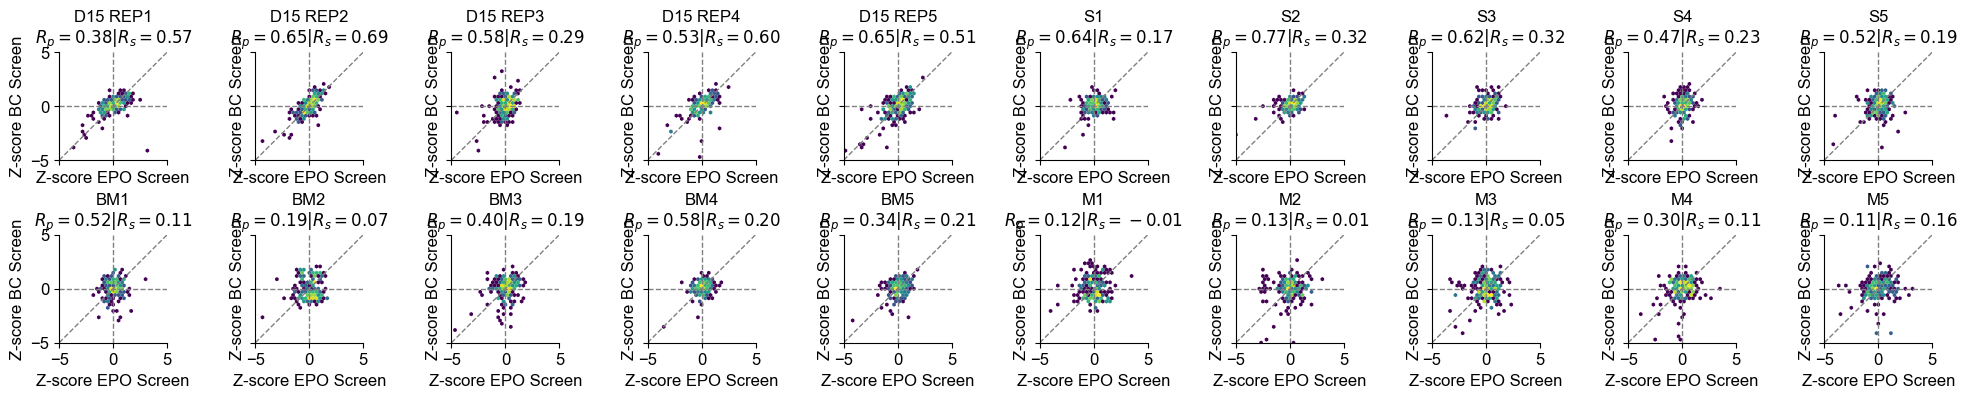

In [ ]:
fig, ax = plt.subplots(2,10,figsize=(20,4), sharey=True, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(ABE_BC_COUNTS.columns[5:]):
            samp = list(ABE_BC_COUNTS.columns)[5:][num_samp]
            
            epo = ABE_EPO_controls[['gRNA_id',samp,'classification']]
            avg = np.average(epo[samp])
            std = np.std(epo[samp])
            epo[f'epo_z_score'] = (epo[samp]-avg)/std
            epo = epo[['gRNA_id','epo_z_score','classification']]

            bc = ABE_BC_controls[['gRNA_id',samp, 'classification']]
            avg = np.average(bc[samp])
            std = np.std(bc[samp])
            bc[f'bc_z_score'] = (bc[samp]-avg)/std
            bc = bc[['gRNA_id','bc_z_score','classification']]
            df = pd.merge(epo, bc)

            # correlation calculation 
            corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
            corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
            spearman = "{:.2f}".format(corr_spearman)
            pearson = "{:.2f}".format(corr_pearson)

            # tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

            # if len(tb)>0:
            #     tb = tb.reset_index(drop=True)
            #     tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
            #     t = []
            #     x = []
            #     y = []
            #     c = []
            #     # print(val)
            #     for _, val2 in tb.iterrows():
            #         y.append(val2[f'bc_z_score'])
            #         x.append(val2['epo_z_score'])
            #         c.append('gray')
            #         t.append(val2['gRNA_id'])

            #     print(len(x))
            #     texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
            #     if i >0:
            #         adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))
            ax[i][k].set_aspect('equal')
            print(len(df))
            color_dict_classification = {'non-targeting control':purples[4], 'safe-targeting control':yellows[4]}
            # sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[i][k], hue='classification', palette=color_dict_classification, s=50, alpha=.6, legend=False)
            ax[i][k].hexbin(df['epo_z_score'], df['bc_z_score'],  bins='log',gridsize=30, linewidth=0, 
                          extent = (-5, 5, -5, 5)
                            )
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].tick_params(axis='both', which='major', labelsize=12,)
            ax[i][k].plot([-5,5],[-5,5], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([0,0],[-5,5], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([-5,5],[0,0], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].set_title(f'{DICT_ABE_BC[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 12)
            ax[i][k].set_ylabel(f'Z-score BC Screen', fontsize=12)
            ax[i][k].set_xlabel(f'Z-score EPO Screen', fontsize=12)
            ax[i][k].set_ylim(-5,5)
            ax[i][k].set_xlim(-5,5)

# for i in range(5,10):
#     fig.delaxes(ax[2][i])
#     ax[1][i].tick_params(labelbottom=True)

fig.tight_layout()
fig.savefig('figures/abe_rep_null_hex.pdf')

In [ ]:
NAMES_CBE_BC  = [
    'Plasmid',
    'Input REP1','Input REP2','Input REP3','Input REP4','Input REP5',
    'D5 REP1','D5 REP2','D5 REP3','D5 REP4','D5 REP5',
    'D15 REP1','D15 REP2','D15 REP3','D15 REP4','D15 REP5',
    'S1','S2','S4',
    'BM1','BM2','BM4',
    'M1','M2','M4'
]
NAMES_CBE_EPO = [
    'Plasmid',
    'Input REP1','Input REP2','Input REP3','Input REP4','Input REP5',
    'D5 REP1','D5 REP2','D5 REP3','D5 REP4','D5 REP5',
    'D15 REP1','D15 REP2','D15 REP3','D15 REP4','D15 REP5',
    'S1','S2','S3','S4','S5',
    'BM1','BM2','BM3','BM4','BM5',
    'M1','M2','M3','M4','M5'
]
DICT_CBE_BC =  dict(zip(list(CBE_BC_COUNTS.columns[2:]), NAMES_CBE_BC))
DICT_CBE_EPO = dict(zip(list(CBE_EPO_COUNTS.columns[2:]), NAMES_CBE_EPO))

In [ ]:
len(CBE_BC_COUNTS.columns[13:])

14

360
360
360
360
360
360
360
360
360
360
360
360
360
360


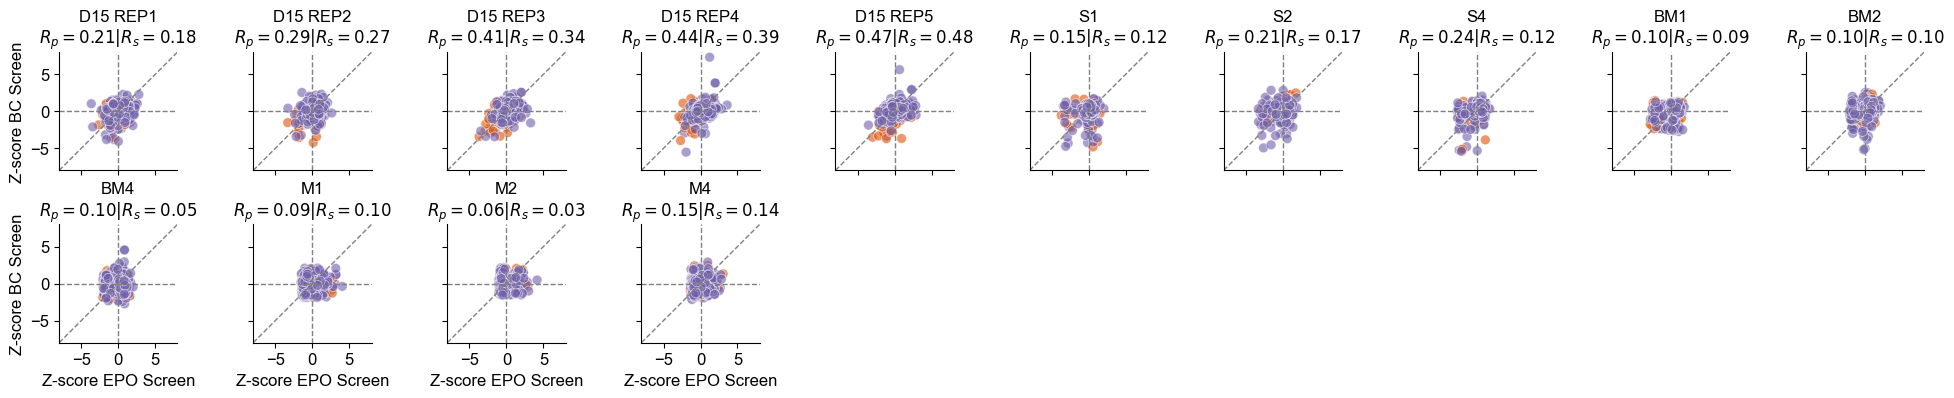

In [ ]:
fig, ax = plt.subplots(2,10,figsize=(20,4), sharey=True, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(CBE_BC_COUNTS.columns[13:]):
            samp = list(CBE_BC_COUNTS.columns)[13:][num_samp]
            
            epo = CBE_EPO_controls[['gRNA_id',samp,'classification']]
            avg = np.average(epo[samp])
            std = np.std(epo[samp])
            epo[f'epo_z_score'] = (epo[samp]-avg)/std
            epo = epo[['gRNA_id','epo_z_score','classification']]

            bc = CBE_BC_controls[['gRNA_id',samp, 'classification']]
            avg = np.average(bc[samp])
            std = np.std(bc[samp])
            bc[f'bc_z_score'] = (bc[samp]-avg)/std
            bc = bc[['gRNA_id','bc_z_score','classification']]
            df = pd.merge(epo, bc)

            # correlation calculation 
            corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
            corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
            spearman = "{:.2f}".format(corr_spearman)
            pearson = "{:.2f}".format(corr_pearson)

            # tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

            # if len(tb)>0:
            #     tb = tb.reset_index(drop=True)
            #     tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
            #     t = []
            #     x = []
            #     y = []
            #     c = []
            #     # print(val)
            #     for _, val2 in tb.iterrows():
            #         y.append(val2[f'bc_z_score'])
            #         x.append(val2['epo_z_score'])
            #         c.append('gray')
            #         t.append(val2['gRNA_id'])

            #     print(len(x))
            #     texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
            #     if i >0:
            #         adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))
            ax[i][k].set_aspect('equal')
            print(len(df))
            color_dict_classification = {'non-targeting control':purples[4], 'safe-targeting control':yellows[4]}
            sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[i][k], hue='classification', palette=color_dict_classification, s=50, alpha=.6, legend=False)
            # ax[i][k].hexbin(df['epo_z_score'], df['bc_z_score'],  bins='log',gridsize=30, linewidth=0, 
            #               extent = (-5, 5, -5, 5)
            #                 )
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].tick_params(axis='both', which='major', labelsize=12,)
            ax[i][k].plot([-8,8],[-8,8], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([0,0],[-8,8], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([-8,8],[0,0], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].set_title(f'{DICT_CBE_BC[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 12)
            ax[i][k].set_ylabel(f'Z-score BC Screen', fontsize=12)
            ax[i][k].set_xlabel(f'Z-score EPO Screen', fontsize=12)
            ax[i][k].set_ylim(-8,8)
            ax[i][k].set_xlim(-8,8)

for i in range(4,10):
    fig.delaxes(ax[1][i])
    ax[1][i].tick_params(labelbottom=True)

fig.tight_layout()
fig.savefig('figures/cbe_rep_null.pdf')

360
360
360
360
360
360
360
360
360
360
360
360
360
360


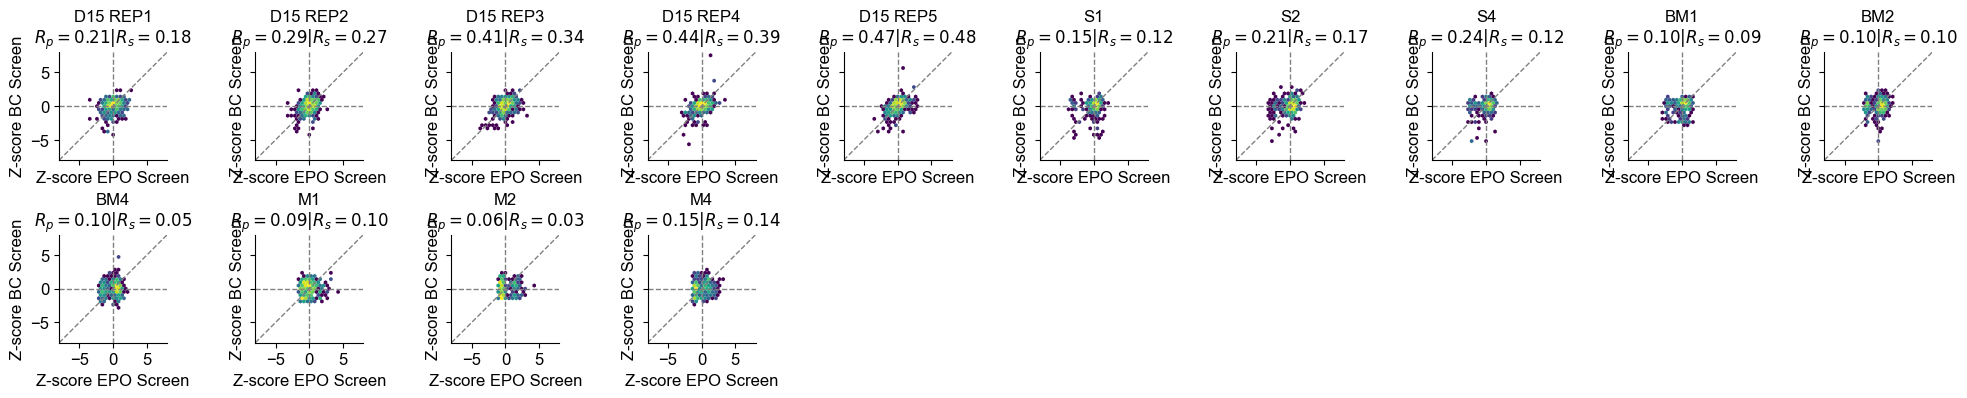

In [ ]:
fig, ax = plt.subplots(2,10,figsize=(20,4), sharey=True, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(CBE_BC_COUNTS.columns[13:]):
            samp = list(CBE_BC_COUNTS.columns)[13:][num_samp]
            
            epo = CBE_EPO_controls[['gRNA_id',samp,'classification']]
            avg = np.average(epo[samp])
            std = np.std(epo[samp])
            epo[f'epo_z_score'] = (epo[samp]-avg)/std
            epo = epo[['gRNA_id','epo_z_score','classification']]

            bc = CBE_BC_controls[['gRNA_id',samp, 'classification']]
            avg = np.average(bc[samp])
            std = np.std(bc[samp])
            bc[f'bc_z_score'] = (bc[samp]-avg)/std
            bc = bc[['gRNA_id','bc_z_score','classification']]
            df = pd.merge(epo, bc)

            # correlation calculation 
            corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['epo_z_score'], df['bc_z_score'])
            corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['epo_z_score'], df['bc_z_score'])
            spearman = "{:.2f}".format(corr_spearman)
            pearson = "{:.2f}".format(corr_pearson)

            # tb = df[(df['epo_z_score']<-1) & (df['bc_z_score']<-1)]

            # if len(tb)>0:
            #     tb = tb.reset_index(drop=True)
            #     tb = tb.sort_values(by='epo_z_score', ascending=True).iloc[:5]
            #     t = []
            #     x = []
            #     y = []
            #     c = []
            #     # print(val)
            #     for _, val2 in tb.iterrows():
            #         y.append(val2[f'bc_z_score'])
            #         x.append(val2['epo_z_score'])
            #         c.append('gray')
            #         t.append(val2['gRNA_id'])

            #     print(len(x))
            #     texts = [ax[0][i].text(x[k], y[k], t[k], fontsize=10, color=c[k], path_effects=[PathEffects.withStroke(linewidth=2, foreground="w")]) for k in range(len(x))]
            #     if i >0:
            #         adjust_text(texts,only_move={'texts':'xy'}, ax=ax[0][i], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'), force_text=(0.5, 0.5))
            ax[i][k].set_aspect('equal')
            print(len(df))
            color_dict_classification = {'non-targeting control':purples[4], 'safe-targeting control':yellows[4]}
            # sns.scatterplot(data=df, x='epo_z_score', y='bc_z_score',ax=ax[i][k], hue='classification', palette=color_dict_classification, s=50, alpha=.6, legend=False)
            ax[i][k].hexbin(df['epo_z_score'], df['bc_z_score'],  bins='log',gridsize=30, linewidth=0, 
                          extent = (-8, 8, -8, 8)
                            )
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].tick_params(axis='both', which='major', labelsize=12,)
            ax[i][k].plot([-8,8],[-8,8], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([0,0],[-8,8], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].plot([-8,8],[0,0], linestyle='dashed', color='gray', linewidth=1)
            ax[i][k].set_title(f'{DICT_CBE_BC[samp]}\n$R_{{p}} = {pearson} | R_{{s}} = {spearman}$', fontsize = 12)
            ax[i][k].set_ylabel(f'Z-score BC Screen', fontsize=12)
            ax[i][k].set_xlabel(f'Z-score EPO Screen', fontsize=12)
            ax[i][k].set_ylim(-8,8)
            ax[i][k].set_xlim(-8,8)

for i in range(4,10):
    fig.delaxes(ax[1][i])
    ax[1][i].tick_params(labelbottom=True)

fig.tight_layout()
fig.savefig('figures/cbe_rep_null_hex.pdf')

In [ ]:
cols_avg = [f'LFC_avg_{x}' for x in ['bm', 'd15', 'd5', 'men', 'spleen']]
cols_median = [f'LFC_median_{x}' for x in ['bm', 'd15', 'd5', 'men', 'spleen']]

[Text(1, 0.5, 'LFC_avg_d15'),
 Text(1, 1.5, 'LFC_avg_d5'),
 Text(1, 2.5, 'LFC_avg_men'),
 Text(1, 3.5, 'LFC_avg_bm'),
 Text(1, 4.5, 'LFC_avg_spleen')]

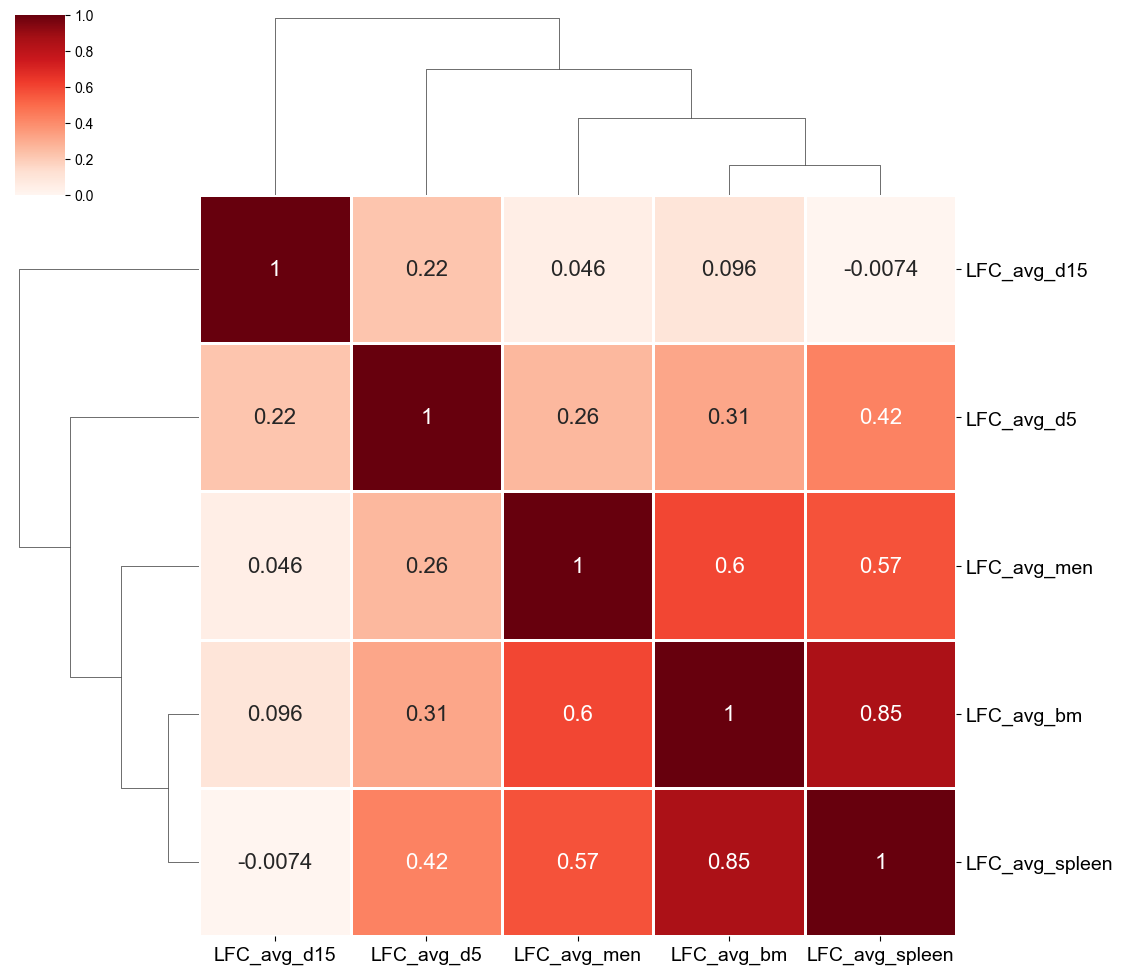

In [ ]:
g = sns.clustermap(ABE_EPO_controls[cols_avg].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
#g.savefig('figures/CBE_editing_heatmap.pdf')

[Text(1, 0.5, 'LFC_avg_d5'),
 Text(1, 1.5, 'LFC_avg_d15'),
 Text(1, 2.5, 'LFC_avg_men'),
 Text(1, 3.5, 'LFC_avg_bm'),
 Text(1, 4.5, 'LFC_avg_spleen')]

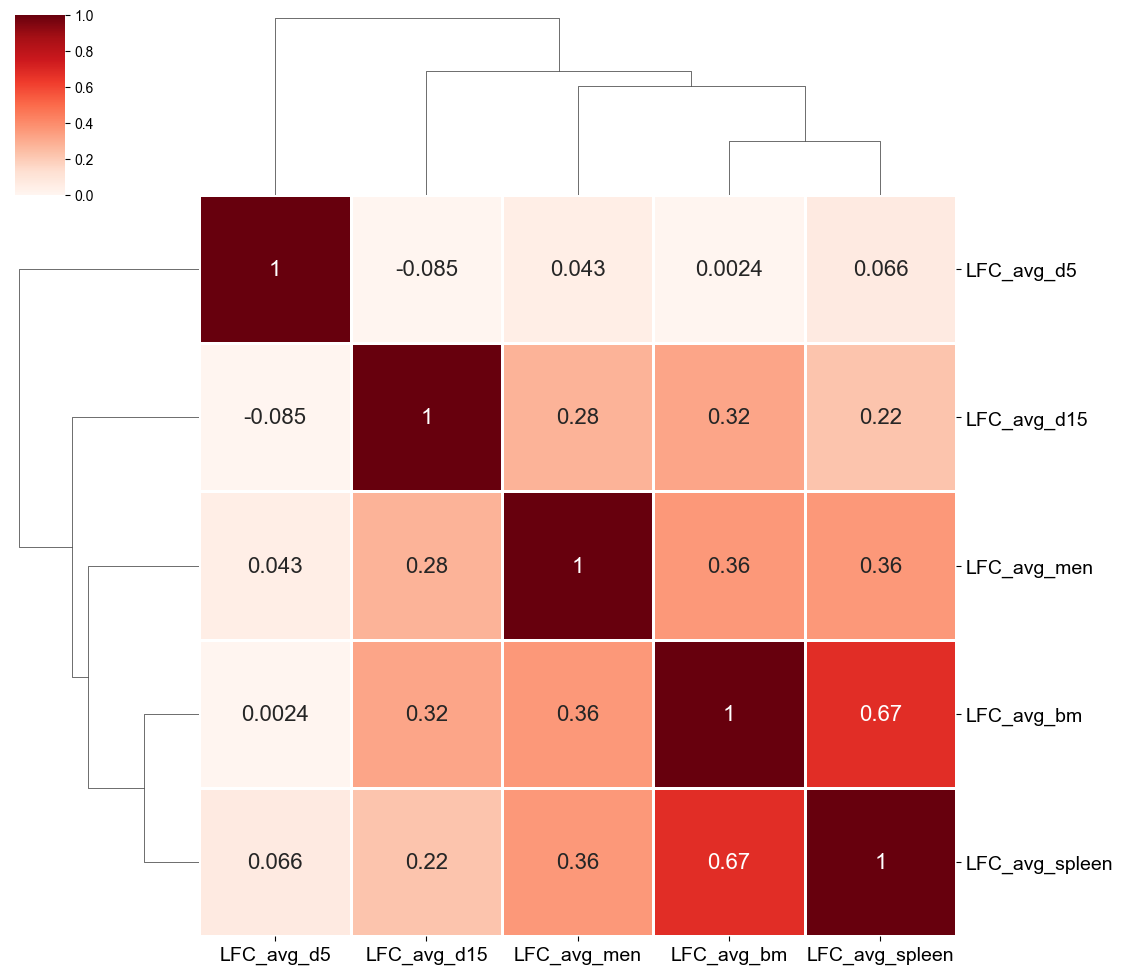

In [ ]:
g = sns.clustermap(CBE_controls[cols_avg].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
#g.savefig('figures/CBE_editing_heatmap.pdf')